<h2>TF-IDF</h2>

Dataset

In [1]:
import pandas as pd 


train = pd.read_csv("./data/train.csv")
val = pd.read_csv("./data/val.csv")
test = pd.read_csv("./data/test.csv")

In [2]:
train.shape
val.shape
test.shape

(9469, 3)

In [3]:
X_train = train[["title", "text"]]
y_train = train["label"]

X_val = val[["title", "text"]]
y_val = val["label"]

X_test = test[["title", "text"]]
y_test = test["label"]

print(val["title"][0])
print(test["title"][0])

When Duterte Met Abe
Trump promised to repeal Obamacare. Now what?


In [4]:
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
import time



title_vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),  
    sublinear_tf=True,   
    norm='l2'
)


text_vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),  
    sublinear_tf=True,   
    norm='l2'
)

start_time = time.perf_counter()

tfidf_title_matrix = title_vectorizer.fit_transform(X_train["title"])
tfidf_text_matrix = text_vectorizer.fit_transform(X_train["text"])
X_train_features = hstack([tfidf_title_matrix, tfidf_text_matrix]).tocsr()


# test and val
tfidf_title_val_matrix = title_vectorizer.transform(X_val["title"])
tfidf_text_val_matrix = text_vectorizer.transform(X_val["text"])
X_val_features = hstack([tfidf_title_val_matrix, tfidf_text_val_matrix]).tocsr()


tfidf_title_test_matrix = title_vectorizer.transform(X_test["title"])
tfidf_text_test_matrix = text_vectorizer.transform(X_test["text"])
X_test_features = hstack([tfidf_title_test_matrix, tfidf_text_test_matrix]).tocsr()

In [5]:
print("train ",X_train_features.shape)

print("validation ",X_val_features.shape)

print("test ",X_test_features.shape)

train  (44184, 6380397)
validation  (9468, 6380397)
test  (9469, 6380397)


<h2>Logistic Regression</h2>

In [6]:
y_train.value_counts(normalize=True)

label
0    0.551172
1    0.448828
Name: proportion, dtype: float64

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score,classification_report

# $0.23/hr for AWS ml.m5.xlarge
HOURLY_INSTANCE_RATE_USD = 0.23


clf = LogisticRegression(
    C=1.0,               
    max_iter=1000,       
    solver='lbfgs',    
    # class_weight='balanced', #0.551172 of 0 and 0.448828 of 1
    random_state=42
)

clf.fit(X_train_features, y_train)
end_time = time.perf_counter()


training_time_sec = end_time - start_time

training_cost_usd = (training_time_sec / 3600.0) * HOURLY_INSTANCE_RATE_USD


In [8]:
y_val_pred = clf.predict(X_val_features)


acc = accuracy_score(y_val, y_val_pred)
class_report = classification_report(y_val, y_val_pred);

print("Validation Accuracy:", acc )
print("Validation F1 score:", class_report)
print("training time: ",training_time_sec)
print("estimated cost: ",training_cost_usd)


Validation Accuracy: 0.9573299535276721
Validation F1 score:               precision    recall  f1-score   support

           0       0.96      0.97      0.96      5219
           1       0.96      0.95      0.95      4249

    accuracy                           0.96      9468
   macro avg       0.96      0.96      0.96      9468
weighted avg       0.96      0.96      0.96      9468

training time:  73.14286320000247
estimated cost:  0.004673016260000158


Matrice du confusion


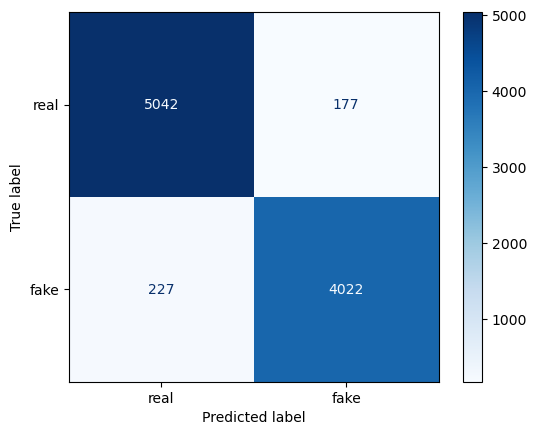

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["real", "fake"])
disp.plot(cmap="Blues")
plt.show()

In [10]:
# Reset index so it lines up cleanly with y_val_pred (which is a plain numpy array, 0-indexed)
X_val_reset = X_val.reset_index(drop=True)
y_val_reset = y_val.reset_index(drop=True)

# Boolean masks for the two error types
false_negatives_mask = (y_val_reset == 1) & (y_val_pred == 0)  # actually fake, predicted real
false_positives_mask = (y_val_reset == 0) & (y_val_pred == 1)  # actually real, predicted fake


false_negatives = X_val_reset[false_negatives_mask]
false_positives = X_val_reset[false_positives_mask]

print("=== FALSE NEGATIVES (fake predicted as real) ===")
print(false_negatives[["title", "text"]].head(3))

print("\n=== FALSE POSITIVES (real predicted as fake) ===")
print(false_positives[["title", "text"]].head(3))

=== FALSE NEGATIVES (fake predicted as real) ===
                                                 title  \
316   This Is Clinton’s Supreme Court Plan, And It ...   
343  Ann Garrison: Clinton Serves the Interests of ...   
387      China's immoral treatment of Africa must stop   

                                                  text  
316  Hillary Clinton is about to step up the fight ...  
343  68 Shares\n67 0 0 1\nMohsen Abdelmoumen : Do y...  
387  License DMCA With the U.S. more interested in ...  

=== FALSE POSITIVES (real predicted as fake) ===
                                                title  \
3   Immigration Puzzle Confounds Republican 2016 F...   
37  FBI’s brazen terrorism lie: What the Boston Ma...   
68  James Comey Denied Leaking Under Oath — Days B...   

                                                 text  
3   Republicans are girding for a 2016 campaign de...  
37  Close to the end of the March 25 testimony in ...  
68  How things have changed. Only nine days